## Homework

1. 使用不同的大模型运行多智能体，对比结果并评选 `gpt-4o` 之下最好的大模型，将所有的大模型和最终结果生成一张表格；
2. 将 `Chart_Generator` 替换为其他功能智能体（如 `table_generator`），为其设计提示词，然后运行查看生成结果。
3. [**可选**]优化研究智能体 `Researcher` 提示词和路由函数 `route` 跳转逻辑，提升图表生成的成功率。

In [1]:
import getpass
import os

# 定义一个帮助函数来检查环境变量，如果不存在则提示用户输入
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"请输入您的 {var}")

# 设置 OpenAI 和 Langchain API 密钥
# _set_if_undefined("OPENAI_API_KEY")
# _set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")

# 可选：在 LangSmith 中添加追踪功能
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "table-generator-agent Collaboration"


In [2]:
from typing import Annotated
import os
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import StructuredTool
from langchain_experimental.utilities import PythonREPL

# Tavily 搜索工具
tavily_tool = TavilySearchResults(max_results=5)

# Python REPL 工具
repl = PythonREPL()

IMAGE_OUTPUT_DIR = "./generated_output_table"
os.makedirs(IMAGE_OUTPUT_DIR, exist_ok=True)

# 使用 StructuredTool 定义工具
def execute_python_func(script: str) -> str:
    """Execute Python code to generate tables."""
    original_dir = os.getcwd()
    os.chdir(IMAGE_OUTPUT_DIR)
    try:
        result = repl.run(script)
        print("\n" + "="*60)
        print("TABLE OUTPUT:")
        print("="*60)
        print(result)
        print("="*60)
        return "Success"
    except Exception as e:
        return f"Error: {e}"
    finally:
        os.chdir(original_dir)

# 使用 StructuredTool 而不是 @tool
execute_python_code = StructuredTool.from_function(
    func=execute_python_func,
    name="execute_python_code",
    description="Execute Python code to generate tables",
    args_schema={
        "type": "object",
        "properties": {
            "script": {
                "type": "string",
                "description": "Python code to execute"
            }
        },
        "required": ["script"]
    }
)

/home/sherry/miniconda3/envs/langchain/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
/tmp/ipykernel_34435/3219740818.py:8: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


In [3]:
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import END, StateGraph, START


# 创建智能体的函数，绑定 LLM（大型语言模型） 和工具
def create_agent(llm, tools, system_message: str):
    """创建一个智能体。"""
    # 定义智能体的提示模板，包含系统消息和工具信息
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant, collaborating with other assistants."
                " Use the provided tools to progress towards answering the question."
                " If you are unable to fully answer, that's OK, another assistant with different tools "
                " will help where you left off. Execute what you can to make progress."
                " If you or any of the other assistants have the final answer or deliverable,"
                " prefix your response with FINAL ANSWER so the team knows to stop."
                " You have access to the following tools: {tool_names}.\n{system_message}",
            ),
            MessagesPlaceholder(variable_name="messages"),  # 用于替换的消息占位符
        ]
    )
    
    # 将系统消息部分和工具名称插入到提示模板中
    prompt = prompt.partial(system_message=system_message)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    
    # 将提示模板与语言模型和工具绑定
    return prompt | llm.bind_tools(tools)


In [4]:
import functools
import json
from langchain_core.messages import BaseMessage, AIMessage, ToolMessage, HumanMessage
from langchain_openai import ChatOpenAI


def normalize_messages_for_api(messages):
    """
    标准化消息以兼容 SiliconFlow API
    SiliconFlow 可能不支持 ToolMessage，需要转换为 AIMessage 格式
    """
    normalized = []
    
    for i, m in enumerate(messages):
        if isinstance(m, HumanMessage):
            msg = HumanMessage(content=m.content)
            normalized.append(msg)

        elif isinstance(m, AIMessage):
            tool_calls = getattr(m, "tool_calls", [])
            if tool_calls:
                msg = AIMessage(
                    content=m.content or "",
                    tool_calls=tool_calls
                )
            else:
                msg = AIMessage(content=m.content or "")
            normalized.append(msg)

        elif isinstance(m, ToolMessage):
            # 关键修复：将 ToolMessage 转换为 AIMessage
            # 因为 SiliconFlow API 可能不支持 role="tool" 的消息
            # 我们将工具结果包装为助手的回复
            tool_name = getattr(m, "name", "tool")
            tool_content = m.content or "(Tool executed successfully)"
            
            # 创建一个包含工具结果的 AIMessage
            msg = AIMessage(
                content=f"[Tool {tool_name} returned]: {tool_content}"
            )
            normalized.append(msg)
    
    return normalized


def agent_node(state, agent, name):
    """Agent 节点函数，处理消息并调用 agent"""
    messages = state["messages"]
    
    print(f"\n[{name}] Processing {len(messages)} messages...", flush=True)
    
    # 清理消息，将 ToolMessage 转换为 AIMessage
    clean_messages = normalize_messages_for_api(messages)
    
    print(f"  After normalization: {len(clean_messages)} messages", flush=True)
    
    try:
        result = agent.invoke({"messages": clean_messages})
        
        if isinstance(result, BaseMessage):
            message = result
        else:
            message = AIMessage(content=str(result))

        message.name = name
        
        print(f"  [{name}] Response OK", flush=True)

        return {
            "messages": [message],
            "sender": name
        }
    except Exception as e:
        print(f"\n  [ERROR in {name}]: {type(e).__name__}: {e}", flush=True)
        print(f"  Messages sent to API:", flush=True)
        for i, msg in enumerate(clean_messages):
            print(f"    [{i}] {type(msg).__name__}", flush=True)
        raise

In [5]:
# 为 Agent 配置各自的大模型
research_llm = ChatOpenAI(model="Pro/deepseek-ai/DeepSeek-V3.2", temperature=0.5)
table_llm = ChatOpenAI(model="Pro/deepseek-ai/DeepSeek-V3.2", temperature=0)

In [6]:
# Researcher 节点 - 不使用 bind_tools，直接调用 LLM
import re

def research_node_hybrid(state):
    """
    Researcher 节点 - 使用 LangGraph 状态管理，但不使用 bind_tools
    直接调用 LLM 生成搜索查询，然后调用搜索工具
    """
    messages = state["messages"]
    
    print(f"\n[Researcher] Processing {len(messages)} messages...", flush=True)
    
    # 检查是否需要执行搜索
    last_message = messages[-1]
    last_content = str(last_message.content) if hasattr(last_message, 'content') else ""
    last_sender = getattr(last_message, 'name', '') or getattr(last_message, 'sender', '')
    
    # 关键修复：检查是否是 Table_Generator 返回的 "Continue..." 消息
    # 如果是，说明我们已经搜索过了，现在需要格式化结果
    if "Continue..." in last_content and last_sender == "Table_Generator":
        # 查找我们之前的搜索结果（从消息历史中）
        search_results = None
        for msg in reversed(messages):
            msg_content = str(msg.content) if hasattr(msg, 'content') else ""
            if "Search results:" in msg_content:
                search_results = msg_content
                break
        
        if search_results:
            # 格式化搜索结果为 RESEARCH_RESULT
            print(f"  [Researcher] Formatting search results...", flush=True)
            
            prompt = f"""Based on these search results, extract structured data for a table:

{search_results}

Return ONLY a JSON in this format:
{{
  "title": "Topic",
  "data": [{{"label": "2020", "value": "21.354"}}],
  "notes": ["note1", "note2"],
  "sources": ["source1"]
}}"""
            
            try:
                response = research_llm.invoke(prompt)
                
                print(f"  [Researcher] Formatted data as RESEARCH_RESULT", flush=True)
                
                return {
                    "messages": [AIMessage(content=f"RESEARCH_RESULT: {response.content}", name="Researcher")],
                    "sender": "Researcher"
                }
            except Exception as e:
                print(f"  [ERROR in Researcher]: {e}", flush=True)
                raise
    
    # 检查是否是我们自己刚返回的搜索结果（避免循环）
    if "Search results:" in last_content and last_sender == "Researcher":
        # 这是我们刚创建的搜索结果消息，说明我们要路由到 Table_Generator 了
        # 但 Router 会处理路由，我们这里不需要做任何事
        # 实际上这种情况不应该发生，因为 Router 会直接路由到 Table_Generator
        print(f"  [Researcher] WARNING: Received own search result, this shouldn't happen", flush=True)
        return {
            "sender": "Researcher"
        }
    
    # 需要执行搜索
    # 提取搜索查询
    prompt = f"""Extract a search query from this request:

{last_content}

Respond ONLY with the search query (no extra text)."""
    
    try:
        response = research_llm.invoke(prompt)
        
        print(f"  [Researcher] Search query: {response.content[:50]}...", flush=True)
        
        # 执行搜索
        search_results = tavily_tool.invoke({"query": response.content})
        
        print(f"  [Researcher] Search completed, got {len(search_results) if hasattr(search_results, '__len__') else 'results'}", flush=True)
        
        # 返回搜索结果
        result_text = f"Search results: {search_results}"
        
        return {
            "messages": [AIMessage(content=result_text, name="Researcher")],
            "sender": "Researcher"
        }
    except Exception as e:
        print(f"\n  [ERROR in Researcher]: {type(e).__name__}: {e}", flush=True)
        raise

In [7]:
# 使用自定义节点，不使用 bind_tools，但保留 LangGraph 的其他功能
import re

def table_node_hybrid(state):
    """
    Table_Generator 节点 - 使用 LangGraph 状态管理，但不使用 bind_tools
    1. 调用 LLM 生成代码
    2. 手动检测并执行代码
    3. 执行后直接返回 FINAL ANSWER
    """
    messages = state["messages"]
    
    print(f"\n[Table_Generator] Processing {len(messages)} messages...", flush=True)
    
    # 检查是否已经执行过代码（避免无限循环）
    for msg in messages:
        if hasattr(msg, 'content') and "FINAL ANSWER" in str(msg.content):
            # 已经有最终答案了，不再处理
            return {
                "messages": [AIMessage(content="Task completed.")],
                "sender": "Table_Generator"
            }
    
    last_message = messages[-1]
    last_content = str(last_message.content) if hasattr(last_message, 'content') else ""
    
    # 检查是否已经有搜索结果需要处理
    if "Search results:" in last_content:
        # 这里有搜索结果，但 Researcher 还没格式化
        # 返回 "Continue..." 让 Researcher 格式化
        print(f"  [Table_Generator] Found search results, asking Researcher to format", flush=True)
        return {
            "messages": [AIMessage(content="Continue...", name="Table_Generator")],
            "sender": "Table_Generator"
        }
    
    # 检查是否需要生成代码（包含 RESEARCH_RESULT）
    if "RESEARCH_RESULT" in last_content:
        # 构建 prompt
        prompt = f"""Generate Python code to create a formatted table for this data:

{last_content}

Respond ONLY with Python code inside ```python and ``` markers. Use pandas to create the table."""
        
        try:
            # 直接调用 LLM（不使用 bind_tools）
            response = table_llm.invoke(prompt)
            
            print(f"  [Table_Generator] LLM response received", flush=True)
            
            # 检查响应中是否包含代码
            code_match = re.search(r'```python\n(.*?)```', response.content, re.DOTALL)
            if not code_match:
                code_match = re.search(r'```\n(.*?)```', response.content, re.DOTALL)
            
            if code_match:
                # 找到代码，执行
                code = code_match.group(1)
                tool_result = execute_python_code.invoke({"script": code})
                
                # 执行完代码后，直接返回 FINAL ANSWER
                return {
                    "messages": [
                        AIMessage(content="FINAL ANSWER: Table generated successfully. See the table output above.", name="Table_Generator")
                    ],
                    "sender": "Table_Generator"
                }
            else:
                # 没有找到代码，返回错误
                return {
                    "messages": [AIMessage(content="ERROR: No code generated. Please try again.")],
                    "sender": "Table_Generator"
                }
        except Exception as e:
            print(f"\n  [ERROR in Table_Generator]: {type(e).__name__}: {e}", flush=True)
            raise
    
    # 其他情况，返回继续处理
    return {
        "messages": [AIMessage(content="Continue...", name="Table_Generator")],
        "sender": "Table_Generator"
    }

In [8]:
from langgraph.prebuilt import ToolNode

tools = [tavily_tool, execute_python_code]  # 使用新的工具名称
tool_node = ToolNode(tools)

In [9]:
import operator
from typing import Annotated, Sequence, TypedDict

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str

In [10]:
workflow = StateGraph(AgentState)

workflow.add_node("Researcher", research_node_hybrid)  # 使用混合方法
workflow.add_node("Table_Generator", table_node_hybrid)  # 使用混合方法
workflow.add_node("call_tool", tool_node)

In [11]:
from typing import Literal

def router(state) -> Literal["call_tool", "__end__", "continue"]:
    messages = state["messages"]
    last_message = messages[-1]
    
    if not messages:
        return "__end__"
    
    # 如果有 FINAL_ANSWER，结束
    if hasattr(last_message, 'content') and isinstance(last_message.content, str):
        if "FINAL ANSWER" in last_message.content:
            return "__end__"
    
    # 如果有工具调用，调用工具
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "call_tool"
    
    # 如果上一条是工具消息，当前应该是 AI 的响应，应该继续
    if len(messages) >= 2:
        second_last = messages[-2]
        if isinstance(second_last, ToolMessage):
            return "continue"
    
    return "continue"

In [12]:
# 为 "Researcher" 添加条件边
workflow.add_conditional_edges(
    "Researcher",
    router,
    {
        "continue": "Table_Generator",  # 改为 Table_Generator
        "call_tool": "call_tool",
        "__end__": END
    },
)

# 为 "Table_Generator" 添加条件边
workflow.add_conditional_edges(
    "Table_Generator",  # 改为 Table_Generator
    router,
    {
        "continue": "Researcher",
        "call_tool": "call_tool",
        "__end__": END
    },
)

# 为 "call_tool" 添加条件边
workflow.add_conditional_edges(
    "call_tool",
    lambda x: x["sender"],
    {
        "Researcher": "Researcher",
        "Table_Generator": "Table_Generator",  # 改为 Table_Generator
    },
)

In [13]:
workflow.add_edge(START, "Researcher")
graph = workflow.compile()

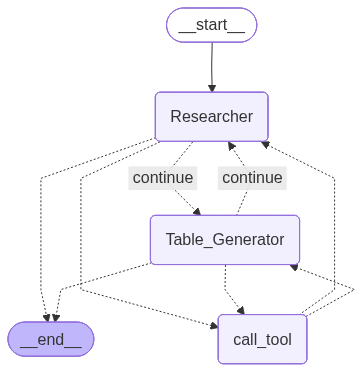

In [14]:
from IPython.display import Image, display

try:
    display(
        Image(
            graph.get_graph(xray=True).draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Error generating graph: {e}")

In [15]:
# 重新编译图（如果节点函数有变化）
# workflow = StateGraph(AgentState)
# workflow.add_node("Researcher", research_node_hybrid)
# workflow.add_node("Table_Generator", table_node_hybrid)
# workflow.add_node("call_tool", tool_node)

# workflow.add_conditional_edges("Researcher", router, {"continue": "Table_Generator", "call_tool": "call_tool", "__end__": END})
# workflow.add_conditional_edges("Table_Generator", router, {"continue": "Researcher", "call_tool": "call_tool", "__end__": END})
# workflow.add_conditional_edges("call_tool", lambda x: x["sender"], {"Researcher": "Researcher", "Table_Generator": "Table_Generator"})

# workflow.add_edge(START, "Researcher")
# graph = workflow.compile()

events = graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Obtain the GDP of the United States from 2020 to 2026, "
                "and then generate a formatted table with Python. End the task after generating the table."
            )
        ],
    },
    {"recursion_limit": 20},
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        last_msg = event["messages"][-1]
        
        if isinstance(last_msg, AIMessage):
            print(f"\n{'='*50}")
            print(f"AI ({event.get('sender', 'unknown')}):")
            print(f"{'='*50}")
            print(last_msg.content[:200] if len(last_msg.content) > 200 else last_msg.content)
        elif isinstance(last_msg, HumanMessage):
            print(f"\n{'='*50}")
            print("Human:")
            print(f"{'='*50}")
            print(last_msg.content)
        elif isinstance(last_msg, ToolMessage):
            print(f"\n{'='*50}")
            print(f"Tool ({last_msg.name}):")
            print(f"{'='*50}")
            print(last_msg.content[:200] if len(last_msg.content) > 200 else last_msg.content)

print("\n" + "="*60)
print("FINAL TABLE OUTPUT (see above)")
print("="*60)


Human:
Obtain the GDP of the United States from 2020 to 2026, and then generate a formatted table with Python. End the task after generating the table.

[Researcher] Processing 1 messages...
  [Researcher] Search query: United States GDP 2020 2021 2022 2023 2024 2025 20...
  [Researcher] Search completed, got 5

AI (Researcher):
Search results: [{'title': 'United States GDP - Trading Economics', 'url': 'https://tradingeconomics.com/united-states/gdp', 'content': "The Gross Domestic Product (GDP) in the United States was worth

[Table_Generator] Processing 2 messages...
  [Table_Generator] Found search results, asking Researcher to format

AI (Table_Generator):
Continue...

[Researcher] Processing 3 messages...
  [Researcher] Formatting search results...
  [Researcher] Formatted data as RESEARCH_RESULT

AI (Researcher):
RESEARCH_RESULT: ```json
{
  "title": "United States GDP (in trillions of US dollars)",
  "data": [
    {"label": "2020", "value": "21.354"},
    {"label": "2021", "val

Python REPL can execute arbitrary code. Use with caution.



TABLE OUTPUT:
United States GDP (in trillions of US dollars)

Year GDP (Trillions USD)
2020              21.354
2021              23.681
2022              26.007
2023              27.721
2024              29.185

Notes:
  • GDP values are in trillions of US dollars (nominal).
  • 2024 value is from World Bank data via Trading Economics.
  • 2020-2023 values are from Macrotrends historical data.

Sources:
  • https://tradingeconomics.com/united-states/gdp
  • https://www.macrotrends.net/global-metrics/countries/usa/united-states/gdp-gross-domestic-product


AI (Table_Generator):
FINAL ANSWER: Table generated successfully. See the table output above.

FINAL TABLE OUTPUT (see above)


In [16]:
  print("TEST - Can you see this?", flush=True)

TEST - Can you see this?


In [17]:
  with open("./debug_agent.log", "r") as f:
      print(f.read())

In [18]:
# 检查 bind_tools 生成的实际工具定义格式
import json

# 绑定工具并查看生成的格式
llm_with_tools = table_llm.bind_tools([execute_python_code])

# 获取绑定后的工具定义
if hasattr(llm_with_tools, 'kwargs') and 'tools' in llm_with_tools.kwargs:
    tools = llm_with_tools.kwargs['tools']
    print("Tools definition from bind_tools:")
    print(json.dumps(tools, indent=2))
else:
    print("No tools found in bound kwargs")
    
# 尝试获取工具定义的其他方式
if hasattr(llm_with_tools, 'bound'):
    print(f"\nBound object: {llm_with_tools.bound}")
    if hasattr(llm_with_tools.bound, 'kwargs'):
        print(f"Bound kwargs: {llm_with_tools.bound.kwargs}")

# 检查 llm_with_tools 的所有属性
print(f"\nllm_with_tools type: {type(llm_with_tools)}")
print(f"llm_with_tools kwargs keys: {list(llm_with_tools.kwargs.keys()) if hasattr(llm_with_tools, 'kwargs') else 'No kwargs'}")

Tools definition from bind_tools:
[
  {
    "type": "function",
    "function": {
      "name": "execute_python_code",
      "description": "Execute Python code to generate tables",
      "parameters": {
        "type": "object",
        "properties": {
          "script": {
            "type": "string",
            "description": "Python code to execute"
          }
        },
        "required": [
          "script"
        ]
      }
    }
  }
]

Bound object: client=<openai.resources.chat.completions.Completions object at 0x725b1ec46a40> async_client=<openai.resources.chat.completions.AsyncCompletions object at 0x725b1ec58b50> root_client=<openai.OpenAI object at 0x725b1ec44970> root_async_client=<openai.AsyncOpenAI object at 0x725b1ec46aa0> model_name='Pro/deepseek-ai/DeepSeek-V3.2' temperature=0.0 model_kwargs={} openai_api_key=SecretStr('**********') openai_api_base='https://api.siliconflow.cn/v1'

llm_with_tools type: <class 'langchain_core.runnables.base.RunnableBinding'>
llm_w

In [19]:
 from langchain_openai import ChatOpenAI

  llm = ChatOpenAI(model="Pro/deepseek-ai/DeepSeek-V3.2")
  response = llm.invoke("Hello")
  print(response.content)

IndentationError: unexpected indent (1977308.py, line 3)